In [1]:
import jax 
#jax.config.update("jax_enable_x64", True)

import lss_utils
import PT_field

import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt

if jax.config.jax_enable_x64:
    print("Using 64-bit precision.")
    base_dtype = jnp.float64
else:
    print("Using 32-bit precision.")
    base_dtype = jnp.float32


Using 32-bit precision.


In [2]:
from scipy.interpolate import CubicSpline

boxsize = 4000
kf = 2 * jnp.pi / boxsize
vol = boxsize**3

ng = 1024
ng_E = 1024

kf = 2 * jnp.pi / boxsize
kny_E = jnp.pi * ng_E / boxsize

print('k_Ny_E = ', kny_E)

redshift = 0.0
OM0 = 0.30964

growth = PT_field.growth_D_f(redshift, OM0)[0] / PT_field.growth_D_f(0, OM0)[0]
growth_f = PT_field.growth_D_f(redshift, OM0)[1]
print(growth, growth_f)
print(jnp.pi*ng/boxsize)

pk_lin = np.loadtxt('/home/akitsukz/field_level/mPk_planck2018_massless_nu.dat')  # @ z=0
pk_lin_interp = CubicSpline(pk_lin[:,0], pk_lin[:,1]* growth**2)

k_Ny_E =  0.8042477193189871
1.0 0.52202797
0.8042477193189871


In [3]:
ng_pad = int(1.5*ng)   ### to avoid aliasing; for the quad fields, 1.5 is recommended, for cubic fields, 2.0 is recommended
ng_L = ng  
ng_L = int(1.1*ng)
if ng_L % 2 !=0:
    ng_L += 1
print(ng_L)

window_order = 2
interlace = True

model = PT_field.LPT_Forward(boxsize=boxsize, ng=ng, ng_L=ng_L, ng_E=ng_E, ng_pad=ng_pad,
                             mas_cfg=(window_order, interlace), 
                             rsd=True, lya=True, lpt_order=1, bias_order=2,
                             #renormalize=False,
                             renormalize=True,
                             dtype=base_dtype,
                             )

seed = 1995

key = jax.random.PRNGKey(seed)
key, subkey = jax.random.split(key)
gauss_3d_r = jax.random.normal(subkey, shape=(ng, ng, ng), dtype=base_dtype)
gauss_3d_r -= jnp.mean(gauss_3d_r)

gauss_3d = jnp.fft.rfftn(gauss_3d_r, norm='ortho') * jnp.sqrt(2.)
gauss_3d = gauss_3d.at[0,0,0].set(0.0)

delta_k = model.linear_modes(pk_lin, gauss_3d)

1126


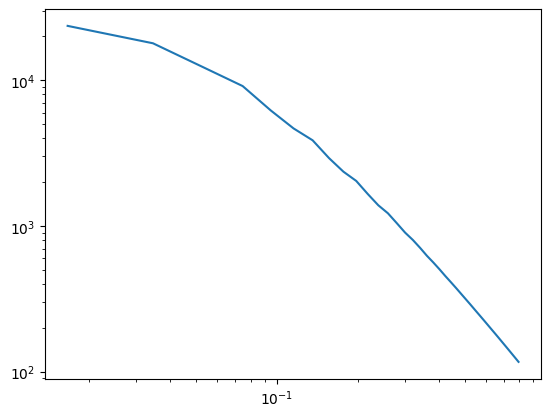

In [4]:
dlnk = 0.02 ### 
k_edges = jnp.linspace(kf, kny_E, int((kny_E-kf)/dlnk))

measure_pk = lss_utils.Measure_Pk(boxsize, ng, k_edges, dtype=base_dtype)

pk_ic = measure_pk(delta_k)

plt.plot(pk_ic[:,0], pk_ic[:,1], label='ICs')

plt.xscale('log')
plt.yscale('log')

#k_arr, pks_auto, Nmodes = PT_field.compute_pks_2d(shifted_fields, mu_edges, measure_pk=measure_pk_E)

#pks_auto: (n_fields, Nk, Nmu)

In [5]:
path = '/home/akitsukz/works/LyA_field/80Mpch_box'

z_arr = np.array([2.0, 2.4, 2.8, 3.2])

beta_params = {}

for z in z_arr:
    beta_params[(z, 'b1')] = np.loadtxt(f'{path}/rsd_b1_fit_zout_{z:.1f}_kmax_1.0.txt')
    beta_params[(z, 'b2')] = np.loadtxt(f'{path}/rsd_b2_fit_zout_{z:.1f}_kmax_1.0.txt')
    beta_params[(z, 'bG2')] = np.loadtxt(f'{path}/rsd_bG2_fit_zout_{z:.1f}_kmax_1.0.txt')
    beta_params[(z, 'b3')] = np.loadtxt(f'{path}/rsd_b3_fit_zout_{z:.1f}_kmax_1.0.txt')
    beta_params[(z, 'bKKpar')] = np.loadtxt(f'{path}/rsd_bKKpar_fit_zout_{z:.1f}_kmax_1.0.txt')
    beta_params[(z, 'beta')] = np.loadtxt(f'{path}/rsd_bEta_fit_zout_{z:.1f}_kmax_1.0.txt')
    beta_params[(z, 'beta2')] = np.loadtxt(f'{path}/rsd_bEta2_fit_zout_{z:.1f}_kmax_1.0.txt')
    beta_params[(z, 'bdeta')] = np.loadtxt(f'{path}/rsd_bdEta_fit_zout_{z:.1f}_kmax_1.0.txt')

def beta_poly_kmu(k,mu,z,bias):
        a0, a01, a1, a11, a12, a14, a21, a4, a22, a44 = beta_params[(z, bias)]
        return a0 + a01 * mu**2 + (a1 + a11 * mu + a12 * mu**2 + a14 * mu**4) * k + (a21 * mu + a4 * k**2 + a22 * mu**2 + a44 * k**2 * mu**4) * k**2

perr_params = {}

for z in z_arr:
    perr_params[(z,)] = np.loadtxt(f'{path}/Perr_fit_zout_{z:.1f}_kmax_1.0.txt')

def perr_poly_kmu(k,mu,z,):
        a0, a2, a3, a4, a22, a33, a44 = beta_params[(z,)]
        return a0 + a2*k**2 + a3*k**3 + a4*k**4 + a22*(k*mu)**2 + a33*(k*mu)**3 + a44*(k*mu)**4


In [6]:
from scipy.interpolate import CubicSpline

def build_beta_kmu_z_spline(beta_params: dict, z_arr: np.ndarray, *, extrapolate: bool = False):
    """
    Build beta(k, mu, z, bias) where the z-dependence is interpolated by CubicSpline.

    beta_params[(z, bias)] must be a length-10 array:
      [a0, a01, a1, a11, a12, a14, a21, a4, a22, a44]
    z_arr must be sorted ascending and match the z keys in beta_params.

    Parameters
    ----------
    extrapolate : bool
        If False, z outside [z_min, z_max] is clamped to the nearest edge.
        If True, CubicSpline extrapolation is used.
    """
    z_grid = np.asarray(z_arr, dtype=float)
    if np.any(np.diff(z_grid) <= 0):
        raise ValueError("z_arr must be strictly increasing.")

    bias_names = sorted({b for (z, b) in beta_params.keys()})
    Nz = z_grid.size
    Ncoef = 10

    coeffs = {}
    for bias in bias_names:
        C = np.empty((Nz, Ncoef), dtype=float)
        for i, z in enumerate(z_grid):
            key = (float(z), bias)
            if key not in beta_params:
                raise KeyError(f"Missing beta_params key={key}")
            v = np.asarray(beta_params[key], dtype=float).reshape(-1)
            if v.size != Ncoef:
                raise ValueError(f"beta_params[{key}] must have length {Ncoef}, got {v.size}")
            C[i] = v
        coeffs[bias] = C

    splines = {
        bias: CubicSpline(z_grid, C, axis=0, extrapolate=True) 
        for bias, C in coeffs.items()
    }

    z_min = float(z_grid[0])
    z_max = float(z_grid[-1])

    def _coeff_at_z(z: float, bias: str) -> np.ndarray:
        if bias not in splines:
            raise KeyError(f"Unknown bias '{bias}'. Available: {list(splines.keys())}")

        zf = float(z)
        if not extrapolate:
            # Clamp outside range
            if zf <= z_min:
                zf = z_min
            elif zf >= z_max:
                zf = z_max

        return np.asarray(splines[bias](zf), dtype=float)  # (10,)

    def beta_kmu_z(k, mu, z, bias: str):
        k = np.asarray(k, dtype=float)
        mu = np.asarray(mu, dtype=float)

        a0, a01, a1, a11, a12, a14, a21, a4, a22, a44 = _coeff_at_z(z, bias)

        mu2 = mu * mu
        mu4 = mu2 * mu2
        k2  = k * k

        return (
            a0
            + a01 * mu2
            + (a1 + a11 * mu + a12 * mu2 + a14 * mu4) * k
            + (a21 * mu + a4 * k2 + a22 * mu2 + a44 * k2 * mu4) * k2
        )

    return beta_kmu_z

def build_perr_kmu_z_spline(perr_params: dict, z_arr: np.ndarray, *, extrapolate: bool = False):
    """
    Build Perr(k, mu, z) where the z-dependence is interpolated by CubicSpline.

    perr_params[(z,)] must be a length-7 array:
      [a0, a2, a3, a4, a22, a33, a44]
    z_arr must be sorted ascending and match the z keys in perr_params.

    Parameters
    ----------
    extrapolate : bool
        If False, z outside [z_min, z_max] is clamped to the nearest edge.
        If True, CubicSpline extrapolation is used.
    """
    z_grid = np.asarray(z_arr, dtype=float)
    if np.any(np.diff(z_grid) <= 0):
        raise ValueError("z_arr must be strictly increasing.")

    Nz = z_grid.size
    Ncoef = 7
    C = np.empty((Nz, Ncoef), dtype=float)

    def _fetch_vec_for_z(zf: float) -> np.ndarray:
        # Accept either keys like (z,) or z
        if (zf, ) in perr_params:
            v = perr_params[(zf, )]
        elif zf in perr_params:
            v = perr_params[zf]
        else:
            raise KeyError(f"Missing perr_params key for z={zf} (tried (z,) and z)")
        v = np.asarray(v, dtype=float).reshape(-1)
        if v.size != Ncoef:
            raise ValueError(f"perr_params[{zf}] must have length {Ncoef}, got {v.size}")
        return v

    for i, z in enumerate(z_grid):
        C[i] = _fetch_vec_for_z(float(z))

    spline = CubicSpline(z_grid, C, axis=0, extrapolate=True)
    z_min = float(z_grid[0])
    z_max = float(z_grid[-1])

    def _coeff_at_z(z: float) -> np.ndarray:
        zf = float(z)
        if not extrapolate:
            if zf <= z_min:
                zf = z_min
            elif zf >= z_max:
                zf = z_max
        return np.asarray(spline(zf), dtype=float)  # (7,)

    def perr_kmu_z(k, mu, z):
        """
        Evaluate Perr polynomial at (k, mu, z) with broadcasting.
        Perr(k, mu, z) = a0 + a2 k^2 + a3 k^3 + a4 k^4
                        + a22 (k mu)^2 + a33 (k mu)^3 + a44 (k mu)^4
        """
        k = np.asarray(k, dtype=float)
        mu = np.asarray(mu, dtype=float)

        a0, a2, a3, a4, a22, a33, a44 = _coeff_at_z(z)

        k2 = k * k
        k3 = k2 * k
        k4 = k2 * k2

        kmu = k * mu
        kmu2 = kmu * kmu
        kmu3 = kmu2 * kmu
        kmu4 = kmu2 * kmu2

        return a0 + a2*k2 + a3*k3 + a4*k4 + a22*kmu2 + a33*kmu3 + a44*kmu4

    return perr_kmu_z


In [7]:
beta_kmu_z = build_beta_kmu_z_spline(beta_params, z_arr, extrapolate=True)
perr_kmu_z = build_perr_kmu_z_spline(perr_params, z_arr, extrapolate=True)

In [8]:
mu_edges = jnp.array([0.0, 0.25, 0.5, 0.75, 1.0])
mu_mid = 0.5 * (mu_edges[1:] + mu_edges[:-1])

print(mu_mid)
measure_pk_E = lss_utils.Measure_Pk(boxsize, ng_E, k_edges, dtype=base_dtype)
k_mean = measure_pk_E.k_mean

z_edges = jnp.linspace(2., 3., 5)
#z_edges = jnp.linspace(0.5, 1.2, 5)
#z_edges = jnp.linspace(0.0, 0.3, 3)
z_mid = 0.5 * (z_edges[1:] + z_edges[:-1])
chi_edges = PT_field.chi_of_z(z_edges, OM0)
D_mid, f_mid = PT_field.growth_D_f(z_mid, OM0)

print(z_edges)
print(chi_edges)

bias_list = ['b1', 'beta', 'b2', 'bG2', 'bdeta', 'beta2', 'bKKpar']
bias_to_idx = {b: i for i, b in enumerate(bias_list)}

beta_kmu_mid = np.zeros((len(z_mid), len(bias_list), len(k_edges)-1, len(mu_mid)), dtype=float)
perr_kmu_mid = np.zeros((len(z_mid), len(k_edges)-1, len(mu_mid)), dtype=float)

for i_z in range(len(z_mid)):
    z = z_mid[i_z]
    perr_kmu_mid[i_z,:,:] = perr_kmu_z(k_mean[:,None], mu_mid[None,:], z)
    for b in bias_list:
        j = bias_to_idx[b]
        beta_kmu_mid[i_z, j] = beta_kmu_z(k_mean[:,None], mu_mid[None,:], z, b)


[0.125 0.375 0.625 0.875]
[2.   2.25 2.5  2.75 3.  ]
[3596.3704 3831.9297 4043.2773 4234.14   4407.526 ]


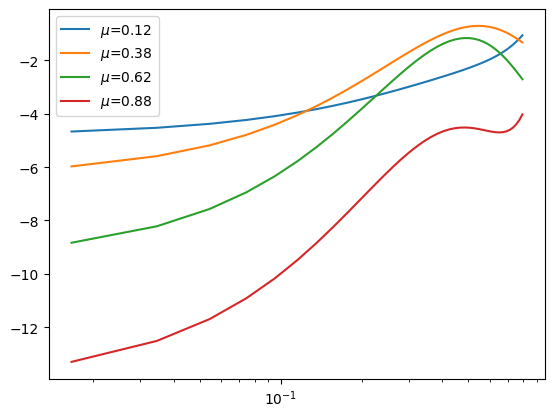

In [9]:
i_z = 3
j_b = 4

for i_mu in range(len(mu_mid)):
    plt.plot(k_mean, beta_kmu_mid[i_z, j_b, :, i_mu], label=rf'$\mu$={mu_mid[i_mu]:.2f}')

plt.xscale('log')
plt.legend()

In [10]:
observer_pos = [boxsize/2, boxsize/2, 0]

final_field_k_lc = model.get_shifted_fields_lightcone_bruteforce(delta_k, 
                                                                 D_ic=PT_field.growth_D_f(redshift, OM0)[0], 
                                                                 chi_edges=chi_edges, D_mid=D_mid, beta_kmu_mid=beta_kmu_mid, 
                                                                 observer_pos=observer_pos,
                                                                 growth_powers=jnp.array([0.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]),
                                                                 f_mid=f_mid,
                                                                 measure_pk=measure_pk_E,
                                                                 k_edges=k_edges,
                                                                 mu_edges=mu_edges,
                                                                 )

In [11]:
key, subkey = jax.random.split(key)
noise_3d_r = jax.random.normal(subkey, shape=(ng_E, ng_E, ng_E), dtype=base_dtype)
noise_3d_r -= jnp.mean(noise_3d_r)

noise_3d = jnp.fft.rfftn(noise_3d_r, norm='ortho') * jnp.sqrt(2.)
noise_3d = noise_3d.at[0,0,0].set(0.0)

noise_field_k_lc = model.get_noise_lightcone(noise_3d,
                                             chi_edges=chi_edges,
                                             observer_pos=observer_pos,
                                             measure_pk=measure_pk_E,
                                             k_edges=k_edges,
                                             mu_edges=mu_edges,
                                             noise_kmu_mid=perr_kmu_mid,
                                             )

In [12]:
field_k_lc = final_field_k_lc + noise_field_k_lc
field_r_lc = model.irfftn(field_k_lc)

In [13]:
def plot_lightcone_slice(field_r_lc,
                         axis='z',
                         index=None,
                         boxsize=None,
                         cmap='RdBu_r',
                         vmin=None,
                         vmax=None):
    """
    Plot a 2D slice of a 3D light-cone field using imshow.

    Parameters
    ----------
    field_r_lc : array_like
        3D real-space field, shape (nx, ny, nz).
        Can be a JAX array or a NumPy array.
    axis : {'x', 'y', 'z'}
        Direction along which to slice.
    index : int or None
        Index of the slice. If None, the central slice is used.
    boxsize : float or None
        Box size in the same units as the field coordinates.
        If provided, it is used to set the imshow extent.
    cmap : str
        Matplotlib colormap.
    vmin, vmax : float or None
        Color scale limits for imshow. If None, they are chosen automatically.
    """
    if isinstance(field_r_lc, jnp.ndarray):
        field = np.array(field_r_lc)
    else:
        field = field_r_lc

    nx, ny, nz = field.shape

    # Choose slice index
    if index is None:
        if axis == 'x':
            index = nx // 2
        elif axis == 'y':
            index = ny // 2
        else:
            index = nz // 2

    # Extract 2D slice
    if axis == 'x':
        slice2d = field[index, :, :]
        xlabel, ylabel = 'y', 'z'
        nx2, ny2 = ny, nz
    elif axis == 'y':
        slice2d = field[:, index, :]
        xlabel, ylabel = 'x', 'z'
        nx2, ny2 = nx, nz
    else:  # 'z'
        slice2d = field[:, :, index]
        xlabel, ylabel = 'x', 'y'
        nx2, ny2 = nx, ny

    # Set extent if boxsize is given
    if boxsize is not None:
        dx = boxsize / nx
        dy = boxsize / ny
        extent = (0.0, boxsize, 0.0, boxsize)
    else:
        extent = None

    plt.figure(figsize=(6, 5))
    im = plt.imshow(
        slice2d.T,      # transpose so that x→horizontal, y→vertical
        origin='lower',
        cmap=cmap,
        extent=extent,
        vmin=vmin,
        vmax=vmax,
        aspect='equal'
    )
    plt.colorbar(im, label='field value')
    plt.xlabel(xlabel if boxsize is None else f'{xlabel} [Mpc/h]')
    plt.ylabel(ylabel if boxsize is None else f'{ylabel} [Mpc/h]')
    plt.title(f'Light-cone slice along {axis}-axis (index = {index})')
    plt.tight_layout()
    plt.show()


In [14]:
field_r_lc.flatten().max()

Array(7.4948564, dtype=float32)

(array([2.24930000e+04, 2.55350000e+04, 2.92950000e+04, 3.32800000e+04,
        3.84520000e+04, 4.39690000e+04, 5.04710000e+04, 5.84340000e+04,
        6.78200000e+04, 7.83600000e+04, 9.09370000e+04, 1.05088000e+05,
        1.21566000e+05, 1.42261000e+05, 1.65582000e+05, 1.94061000e+05,
        2.27425000e+05, 2.67593000e+05, 3.13828000e+05, 3.68560000e+05,
        4.35168000e+05, 5.11981000e+05, 6.05122000e+05, 7.15873000e+05,
        8.47859000e+05, 1.00361000e+06, 1.19152300e+06, 1.40780400e+06,
        1.66778200e+06, 1.97491700e+06, 2.33447400e+06, 2.75225300e+06,
        3.23968900e+06, 3.79722500e+06, 4.44259500e+06, 5.15630200e+06,
        5.95720700e+06, 6.82554000e+06, 7.74899500e+06, 8.68819400e+06,
        9.60244800e+06, 1.04265050e+07, 8.82127997e+08, 1.15082120e+07,
        1.16420300e+07, 1.14499980e+07, 1.09540340e+07, 1.01676540e+07,
        9.18177600e+06, 8.08027100e+06, 6.94044500e+06, 5.84066400e+06,
        4.81529800e+06, 3.90491400e+06, 3.11507400e+06, 2.451241

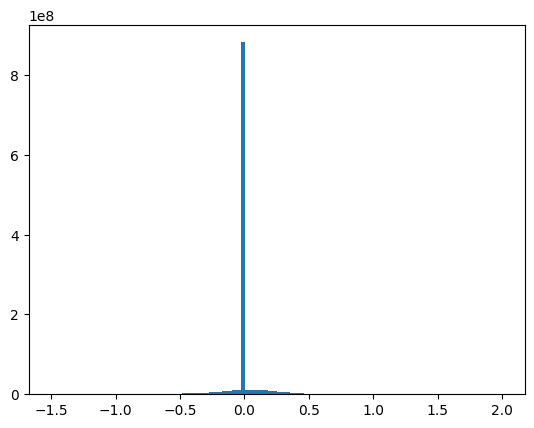

In [17]:
plt.hist(field_r_lc.flatten(), bins=100, range=(-1.5, 2))

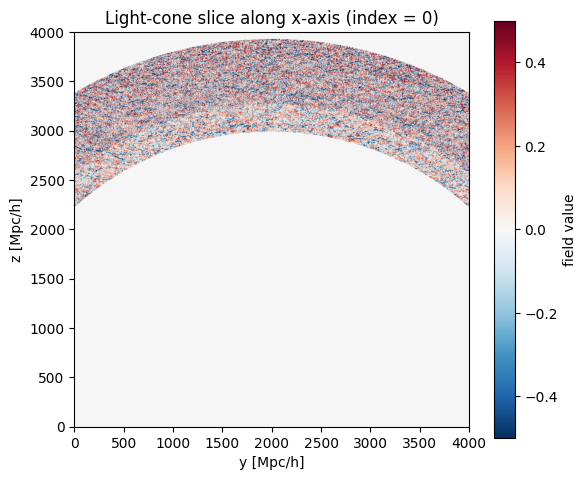

In [18]:
plot_lightcone_slice(
    field_r_lc,
    axis='x',         
    index=0,        # specify an int
    boxsize=model.boxsize,
    cmap='RdBu_r',
    vmin=-0.5, vmax=0.5,
)
